# Imports

In [1]:
!pip install keras-tuner -q
import keras_tuner as kt

2026-06-16 12:27:27.741879: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781612847.969450      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781612848.047066      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781612848.593111      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781612848.593156      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781612848.593159      58 computation_placer.cc:177] computation placer alr

In [2]:
import os
import time
import random
import kagglehub
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from scipy.signal import filtfilt
from scipy.interpolate import griddata

import tensorflow as tf
from tensorflow.keras import models, layers, optimizers, utils
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Download dataset 
abdulkareembageri_imagined_speech_eeg_signal_bci2020_path = "/kaggle/input/datasets/abdulkareembageri/imagined-speech-eeg-signal-bci2020"
# print('Data source import complete.')

# Helper Functions and Data Loading

In [3]:
# === Helper function to recursively convert mat_struct to dictionary ===
def _check_keys(d):
    for key in d:
        if isinstance(d[key], scipy.io.matlab.mio5_params.mat_struct):
            d[key] = _todict(d[key])
    return d

def _todict(matobj):
    d = {}
    for strg in matobj._fieldnames:
        elem = getattr(matobj, strg)
        if isinstance(elem, scipy.io.matlab.mio5_params.mat_struct):
            d[strg] = _todict(elem)
        else:
            d[strg] = elem
    return d

# Load the MATLAB data matrix
file_path = abdulkareembageri_imagined_speech_eeg_signal_bci2020_path + "/BCI2020 EEG Signal for Words/Training set/Data_Sample01.mat"
mat_data = scipy.io.loadmat(file_path, struct_as_record=False, squeeze_me=True)
mat_data = _check_keys(mat_data)

epo_train = mat_data['epo_train']
mnt = mat_data['mnt']

# Accessing epo_train fields
data = epo_train['x']           # EEG data: shape (samples, channels, trials)
labels = epo_train['y']         # Labels: shape (num_classes, trials)

# Accessing mnt fields (channel positions)
mnt_x = mnt['x'][0]             # x-coordinates: (64,)
mnt_y = mnt['y'][0]             # y-coordinates: (64,)

/tmp/ipykernel_58/3491062461.py:4: DeprecationWarning: Please import `mat_struct` from the `scipy.io.matlab` namespace; the `scipy.io.matlab.mio5_params` namespace is deprecated and will be removed in SciPy 2.0.0.
  if isinstance(d[key], scipy.io.matlab.mio5_params.mat_struct):
/tmp/ipykernel_58/3491062461.py:12: DeprecationWarning: Please import `mat_struct` from the `scipy.io.matlab` namespace; the `scipy.io.matlab.mio5_params` namespace is deprecated and will be removed in SciPy 2.0.0.
  if isinstance(elem, scipy.io.matlab.mio5_params.mat_struct):


# Channel Configurations

In [4]:
# Channel Labeling Map
label_to_channel = {
    'Fp1': 1, 'Fp2': 2, 'F7': 3, 'F3': 4, 'Fz': 5, 'F4': 6,
    'F8': 7, 'FC5': 8, 'FC1': 9, 'FC2': 10, 'FC6': 11, 'T7': 12,
    'C3': 13, 'Cz': 14, 'C4': 15, 'T8': 16, 'TP9': 17, 'CP5': 18,
    'CP1': 19, 'CP2': 20, 'CP6': 21, 'TP10': 22, 'P7': 23, 'P3': 24,
    'Pz': 25, 'P4': 26, 'P8': 27, 'PO9': 28, 'O1': 29, 'Oz': 30,
    'O2': 31, 'PO10': 32, 'AF7': 33, 'AF3': 34, 'AF4': 35, 'AF8': 36,
    'F5': 37, 'F1': 38, 'F2': 39, 'F6': 40, 'FT9': 41, 'FT7': 42,
    'FC3': 43, 'FC4': 44, 'FT8': 45, 'FT10': 46, 'C5': 47, 'C1': 48,
    'C2': 49, 'C6': 50, 'TP7': 51, 'CP3': 52, 'CPz': 53, 'CP4': 54,
    'TP8': 55, 'P5': 56, 'P1': 57, 'P2': 58, 'P6': 59, 'PO7': 60,
    'PO3': 61, 'POz': 62, 'PO4': 63, 'PO8': 64
}

# Channel subsets Configurations
Channels1 = ["AF3","F7","F3","FC5","T7","P7","O1","O2","P8","T8","FC6","F4","F8","AF4"]
Channels2 = ["AF3","F7","F3","F4","F8","AF4","AF7","AF8","Fp1","Fp2","F2","F6","Fz","F1","F5"]
Channels3 = ["F7","F3","FC5","T7","P7","C3"]
Channels4 = ["F7","F3","FC5","FC6","F4","T7","T8","C3","C4","P7","P8","O1","O2","CP5","CP6","Cz","P3","P4","POz"]
Channels5 = ["F3","FC5","C3","F4","FC6","C4","Cz"]

# Select your targeted channel group
selected = Channels4

# Preallocate and Map Channels
selected_channels = np.zeros(len(selected), dtype=int)
for i in range(len(selected)):
    selected_channels[i] = label_to_channel[selected[i]] - 1 # Adjusted for 0-based indexing

# EEG Signal Windowing

In [5]:
# Parameters
fs = 256               # Sampling frequency (Hz)
win_ms = 125           # Window length (milliseconds)
overlap_percent = 50   # Desired overlap (in percentage)

# Calculations
win_samples = round(fs * win_ms / 1000)                      # Samples per window
overlap_samples = round(win_samples * overlap_percent / 100)  # Overlap samples
step_samples = win_samples - overlap_samples                 # Step size
total_samples = epo_train['x'].shape[0]                      # Total time samples

n_maps = int(np.floor((total_samples - overlap_samples) / step_samples))  # Number of windows/maps
map_size = 32

# Select coordinates for selected channels
x_sel = mnt['x'][selected_channels]
y_sel = mnt['y'][selected_channels]

# Create meshgrid for interpolation
xi, yi = np.meshgrid(
    np.linspace(np.min(x_sel), np.max(x_sel), map_size),
    np.linspace(np.min(y_sel), np.max(y_sel), map_size)
)

start_map = 6
end_map = 44
tot_map = end_map - start_map + 1
n_train_trials = epo_train['x'].shape[2]

# Signal Preprocessing (Notch Filter + CAR)

In [6]:
# Notch Filter Configuration
f0 = 40   # Notch frequency
Q = 35    # Quality factor
w0 = 2 * np.pi * f0 / fs
alpha = np.sin(w0) / (2 * Q)

b_notch = np.array([1, -2 * np.cos(w0), 1]) / (1 + alpha)
a_notch = np.array([1 + alpha, -2 * np.cos(w0), 1 - alpha]) / (1 + alpha)

# Copy data to preserve original
all_data = epo_train['x']
filtered_data = np.copy(all_data)
n_trials = filtered_data.shape[2]
n_channels = filtered_data.shape[1]

# Apply notch filter
for t in range(n_trials):
    for ch in range(n_channels):
        signal = filtered_data[:, ch, t]
        filtered_data[:, ch, t] = filtfilt(b_notch, a_notch, signal)

# Apply Common Average Referencing (CAR) per trial
for t in range(n_trials):
    trial = filtered_data[:, :, t]
    trial = trial - np.mean(trial, axis=1, keepdims=True)
    filtered_data[:, :, t] = trial

# Save to cloned structure
epo_train_car = dict(epo_train)
epo_train_car['x'] = filtered_data

# Topographic Map Gen

In [7]:
# Initialize 5D tensor
map_size = xi.shape[0]
topo_maps_rgb_5D = np.zeros((map_size, map_size, 3, n_maps, n_train_trials))

# Main Loop Over Trials to generate topographic representations
for t in range(n_train_trials):
    data = epo_train_car['x'][:, selected_channels, t]

    for w in range(n_maps):
        start_idx = (w) * step_samples
        end_idx = start_idx + win_samples

        if end_idx > total_samples:
            break

        segment = np.mean(data[start_idx:end_idx, :], axis=0)
        segment = segment.astype(np.float64).flatten()

        zi = griddata((x_sel.flatten(), y_sel.flatten()), segment, (xi, yi), method='cubic')

        # Map normalization
        zi_min, zi_max = np.nanmin(zi), np.nanmax(zi)
        zi_norm = (zi - zi_min) / (zi_max - zi_min + np.finfo(float).eps)

        # Convert to RGB via Jet Colormap
        cmap = cm.get_cmap('jet', 256)
        rgb_map = cmap((zi_norm * 255).astype(np.uint8))[:, :, :3]

        topo_maps_rgb_5D[:, :, :, w, t] = rgb_map

# Final reshaping for CNN input: [H x W x 3 x tot_map x num_trials]
topo_maps_rgb_5D = topo_maps_rgb_5D[:, :, :, start_map-1:end_map, :]
topo_maps_rgb_5D = topo_maps_rgb_5D.reshape((map_size, map_size, 3, tot_map, -1))

print("Topographic processing complete. Shape:", topo_maps_rgb_5D.shape)

/tmp/ipykernel_58/1668676988.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet', 256)
/tmp/ipykernel_58/1668676988.py:27: RuntimeWarning: invalid value encountered in cast
  rgb_map = cmap((zi_norm * 255).astype(np.uint8))[:, :, :3]


Topographic processing complete. Shape: (32, 32, 3, 39, 300)


# 3-Class Target Label Filtering

In [8]:
# Label Preparation and Conversion
label_vector = epo_train['y']
label_idx = np.argmax(label_vector, axis=0)
classNames = np.array(["Hello", "Help me", "Stop", "Thank you", "Yes"])

# Filter down to 3 Target classes
target_class_names = ["Hello", "Help me", "Stop"]
original_label_vector = epo_train['y']
original_label_indices = np.argmax(original_label_vector, axis=0)

target_class_original_indices = np.array([np.where(classNames == name)[0][0] for name in target_class_names])
mask = np.isin(original_label_indices, target_class_original_indices)

# Filter topographic maps and labels using the mask
topo_maps_rgb_5D = topo_maps_rgb_5D[:, :, :, :, mask]
filtered_original_label_indices = original_label_indices[mask]

original_to_new_label_map = {orig_idx: new_idx for new_idx, orig_idx in enumerate(target_class_original_indices)}
label_idx = np.array([original_to_new_label_map[idx] for idx in filtered_original_label_indices])

classNames = np.array(target_class_names)
labels = pd.Categorical(classNames[label_idx])
n_train_trials = topo_maps_rgb_5D.shape[-1]

print(f"Filtered data to {len(classNames)} classes: {', '.join(classNames)}")
print(f"New total trials: {n_train_trials}")

Filtered data to 3 classes: Hello, Help me, Stop
New total trials: 180


# Network Input Reshaping

In [9]:
# Label Preparation
numClasses = len(np.unique(labels))
label_indices = utils.to_categorical(
    [np.where(classNames == label)[0][0] for label in labels],
    numClasses
)

# Reshape data to match CNN conventions: [N, H, W, C, T]
topo_maps = np.transpose(topo_maps_rgb_5D, (4, 0, 1, 2, 3))
inputSize = (map_size, map_size, 3, tot_map)  # [H, W, C, T]

print("Data tensor shaped for Keras:", topo_maps.shape)

Data tensor shaped for Keras: (180, 32, 32, 3, 39)


# Splitting the data

In [10]:
# 1. ISOLATE 42 SAMPLES FOR TEST DATA (14 PER CLASS)
# =====================================================================
X_temp, X_test, Y_temp, Y_test = train_test_split(
    topo_maps,
    label_indices,
    test_size= 30,  # Exactly 42 unseen real samples
    random_state=42,
    stratify=np.argmax(label_indices, axis=1)
)

print("Data Split Layout:")
print(f" - Held-out Test Data: {X_test.shape[0]} samples (Kept purely unseen)")
print(f" - Remaining Real Train Data: {X_temp.shape[0]} samples\n")

Data Split Layout:
 - Held-out Test Data: 30 samples (Kept purely unseen)
 - Remaining Real Train Data: 150 samples



# Class Augmentation

In [11]:
# 2. TARGETED AUGMENTATION (Adding exactly 62 samples at 0.015 noise)
# =====================================================================
def augment_eeg_data(data, noise_factor=0.05):
    noise = np.random.normal(loc=0.0, scale=noise_factor, size=data.shape)
    return data + noise

# Define EXACTLY how many synthetic samples to ADD to each class to reach 62 total
augment_additions = {
    "Hello": 5,
    "Help me": 40,
    "Stop": 70
}

new_topo_maps = [X_temp] # Start with the 138 real samples
new_labels = [Y_temp]

# Iterate through each class in the training set
for i, class_name in enumerate(classNames):
    class_indices = np.where(np.argmax(Y_temp, axis=1) == i)[0]
    X_class = X_temp[class_indices]
    Y_class = Y_temp[class_indices]

    # Check how many we need to add for this specific class
    needed = augment_additions[class_name]

    if needed > 0:
        # Generate the exact amount of synthetic samples needed
        X_aug = augment_eeg_data(X_class[:needed], noise_factor=0.015)
        new_topo_maps.append(X_aug)
        new_labels.append(Y_class[:needed])

# Overwrite X_temp and Y_temp to be the newly augmented versions
X_temp = np.concatenate(new_topo_maps, axis=0)
Y_temp = np.concatenate(new_labels, axis=0)

print("=== Final Training Set Composition ===")
unique, counts = np.unique(np.argmax(Y_temp, axis=1), return_counts=True)
for name, count in zip(classNames, counts):
    print(f" -> {name}: {count} total samples")
print(f"Total Training/Tuning set size: {X_temp.shape[0]} samples\n")

=== Final Training Set Composition ===
 -> Hello: 55 total samples
 -> Help me: 90 total samples
 -> Stop: 100 total samples
Total Training/Tuning set size: 245 samples



# Main Split + Model Training & 9-Fold Cross-Val

In [12]:
# =====================================================================
# 2. DEFINE THE HYPERPARAMETER SEARCH SPACE
# =====================================================================
def build_tuning_model(hp):
    model = models.Sequential()
    model.add(layers.InputLayer(input_shape=inputSize))

    # Tune the number of filters in the 3D Convolutional layers
    model.add(layers.Conv3D(
        filters=hp.Int('conv_1_filters', min_value=16, max_value=64, step=16),
        kernel_size=3, padding='same', activation='relu'
    ))
    model.add(layers.MaxPooling3D(pool_size=(2, 2, 1)))

    model.add(layers.Conv3D(
        filters=hp.Int('conv_2_filters', min_value=32, max_value=128, step=32),
        kernel_size=3, padding='same', activation='relu'
    ))
    model.add(layers.MaxPooling3D(pool_size=(2, 2, 1)))

    model.add(layers.Conv3D(
        filters=hp.Int('conv_3_filters', min_value=64, max_value=256, step=64),
        kernel_size=3, padding='same', activation='relu'
    ))

    model.add(layers.Permute((4, 1, 2, 3)))
    model.add(layers.TimeDistributed(layers.Flatten()))

    # Tune the number of units in the LSTM layer
    model.add(layers.LSTM(
        units=hp.Int('lstm_units', min_value=64, max_value=256, step=64),
        return_sequences=False
    ))

    # Tune Dense layers units
    model.add(layers.Dense(
        units=hp.Int('dense_1_units', min_value=64, max_value=256, step=64),
        activation='relu'
    ))
    model.add(layers.Dropout(rate=hp.Float('dropout_1', min_value=0.45, max_value=0.55, step=0.1)))

    model.add(layers.Dense(
        units=hp.Int('dense_2_units', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    model.add(layers.Dropout(rate=hp.Float('dropout_2', min_value=0.45, max_value=0.55, step=0.1)))

    model.add(layers.Dense(numClasses, activation='softmax'))

    # Tune Learning Rate
    lr_choice = hp.Choice('learning_rate', values=[1e-4, 5e-4, 1e-3])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr_choice),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 3. RUN HYPERPARAMETER TUNING (Now using the balanced X_temp)
X_tune_train, X_tune_val, Y_tune_train, Y_tune_val = train_test_split(
    X_temp, Y_temp,
    test_size=0.15, # Use 15% of the remaining 144 samples for the tuner
    random_state=42,
    stratify=np.argmax(Y_temp, axis=1)
)

print("--- Launching Hyperparameter Optimization Search ---")
tuner = kt.RandomSearch(
    build_tuning_model,
    objective='val_accuracy',
    max_trials=12,
    executions_per_trial=1,
    directory='tuning_results',
    project_name='eeg_speech_tuning',
    overwrite=True
)

tuner.search(
    X_tune_train, Y_tune_train,
    validation_data=(X_tune_val, Y_tune_val),
    epochs=40,
    batch_size=32,
    verbose=1
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n=== OPTIMAL HYPERPARAMETERS FOUND ===")
print(f" -> Conv Layer 1 Filters: {best_hps.get('conv_1_filters')}")
print(f" -> Conv Layer 2 Filters: {best_hps.get('conv_2_filters')}")
print(f" -> Conv Layer 3 Filters: {best_hps.get('conv_3_filters')}")
print(f" -> LSTM Layer Units:     {best_hps.get('lstm_units')}")
print(f" -> Dense Layer 1 Units:  {best_hps.get('dense_1_units')}")
print(f" -> Dense Layer 2 Units:  {best_hps.get('dense_2_units')}")
print(f" -> Dropout Rate 1:       {best_hps.get('dropout_1'):.2f}")
print(f" -> Dropout Rate 2:       {best_hps.get('dropout_2'):.2f}")
print(f" -> Learning Rate:        {best_hps.get('learning_rate')}\n")


# =====================================================================
# 4. RUN 9-FOLD CV USING THE OPTIMIZED HYPERPARAMETERS & COLLECT PREDICTIONS
# =====================================================================
print("--- Initializing 9-Fold Cross-Validation with Best Hyperparameters ---")
k = 9
kf = KFold(n_splits=k, shuffle=True, random_state=42)
accuracy_per_fold = []
all_folds_test_preds = [] # Stores test probability outputs from every single fold

totalTime = time.time()

for fold, (trainIdx, valIdx) in enumerate(kf.split(X_temp)):
    foldTime = time.time()

    XTrain, XVal = X_temp[trainIdx], X_temp[valIdx]
    YTrain, YVal = Y_temp[trainIdx], Y_temp[valIdx]

    # Rebuild a completely fresh model structure using our discovered best settings
    model = tuner.hypermodel.build(best_hps)

    from tensorflow.keras.callbacks import EarlyStopping

    # Define this before your model.fit()
    early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=15,               # How many epochs to wait before stopping
    restore_best_weights=True  # Always keep the best version of the model
    )

    # Update your model.fit to include the callback
    model.fit(
    XTrain, YTrain,
    validation_data=(XVal, YVal),
    batch_size=32,
    epochs=150,
    verbose=0,
    callbacks=[early_stopper]
    )

    # Calculate validation metrics for the current fold
    YPred_val = np.argmax(model.predict(XVal), axis=1)
    YTrue_val = np.argmax(YVal, axis=1)
    acc = np.mean(YPred_val == YTrue_val)
    accuracy_per_fold.append(acc)

    # CRITICAL ENSEMBLE STEP: Capture how this fold's unique weights predict the test data
    fold_test_predictions = model.predict(X_test)
    all_folds_test_preds.append(fold_test_predictions)

    print(f"Fold {fold+1} Validation Accuracy: {acc*100:.2f}% | Time: {time.time()-foldTime:.2f} seconds")

# Final K-Fold Summary
totalElapsed = time.time() - totalTime
print(f"\nCross-Validation Average Validation Accuracy: {np.mean(accuracy_per_fold)*100:.2f}%")
print(f"Total Training Time: {totalElapsed:.2f} seconds ({totalElapsed/60:.2f} minutes)")


# =====================================================================
# 5. EVALUATION VIA ROBUST ENSEMBLE VOTING ON UNSEEN TEST DATA (10%)
# =====================================================================
print("\n================ EVALUATING VIA 9-FOLD ENSEMBLE ON TEST DATA ================")

# Average out the prediction probability matrices across all 9 trained models
ensemble_test_probabilities = np.mean(all_folds_test_preds, axis=0)

# Generate stable variables for all downstream evaluation, reports, and plotting cells
allYPred = np.argmax(ensemble_test_probabilities, axis=1)
allYTrue = np.argmax(Y_test, axis=1)

# Calculate robust ensemble test accuracy
ensemble_test_accuracy = np.mean(allYPred == allYTrue) * 100
print(f"Final Robust Ensemble Test Accuracy: {ensemble_test_accuracy:.2f}%")

# Save final optimized model structure artifact
model.save("3DCNN+LSTM_Optimized.h5")

Trial 12 Complete [00h 00m 37s]
val_accuracy: 0.8918918967247009

Best val_accuracy So Far: 0.9729729890823364
Total elapsed time: 00h 05m 44s

=== OPTIMAL HYPERPARAMETERS FOUND ===
 -> Conv Layer 1 Filters: 16
 -> Conv Layer 2 Filters: 64
 -> Conv Layer 3 Filters: 192
 -> LSTM Layer Units:     128
 -> Dense Layer 1 Units:  256
 -> Dense Layer 2 Units:  32
 -> Dropout Rate 1:       0.55
 -> Dropout Rate 2:       0.45
 -> Learning Rate:        0.001

--- Initializing 9-Fold Cross-Validation with Best Hyperparameters ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Fold 1 Validation Accuracy: 82.14% | Time: 30.43 seconds
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Fold 2 Validation Accuracy: 92.86% | Time: 38.80 seconds
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Fold 3 Validation Accuracy: 92.59% | Time: 33.02 seconds
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Fold 4 Validatio

Fold 9 Validation Accuracy: 81.48% | Time: 31.06 seconds

Cross-Validation Average Validation Accuracy: 84.88%
Total Training Time: 300.75 seconds (5.01 minutes)

================ EVALUATING VIA 9-FOLD ENSEMBLE ON TEST DATA ================
Final Robust Ensemble Test Accuracy: 63.33%


# Downstream Confusion Matrix

<Figure size 800x600 with 0 Axes>

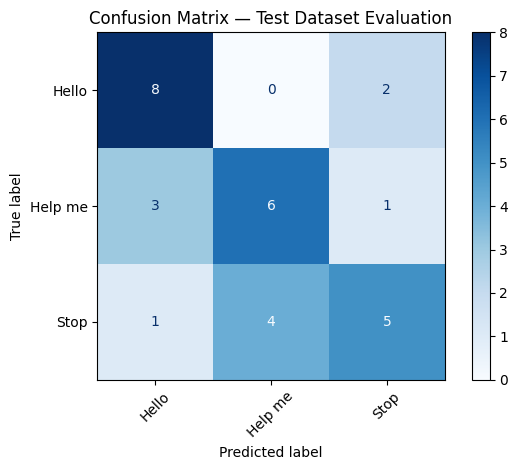

In [13]:
# Create and display confusion matrix on the test data outputs
cm_matrix = confusion_matrix(allYTrue, allYPred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_matrix, display_labels=classNames)

plt.figure(figsize=(8, 6))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — Test Dataset Evaluation")
plt.tight_layout()
plt.show()

# Classification Performance Chart

<Figure size 1000x500 with 0 Axes>

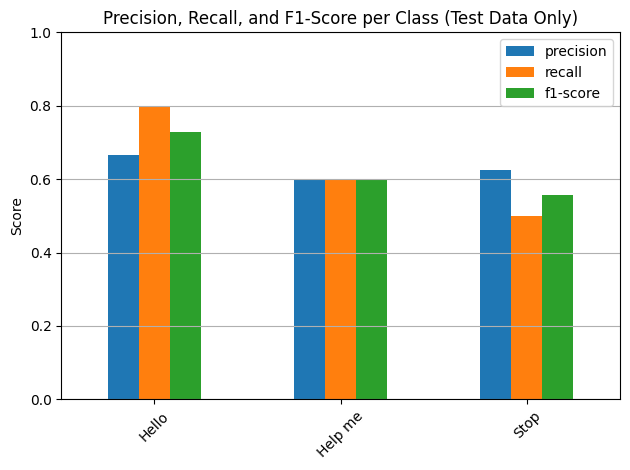

In [14]:
# Generate classification report
report = classification_report(allYTrue, allYPred, target_names=classNames, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Drop aggregate metrics for class-based chart
df_report_classes = df_report.iloc[:-3]

plt.figure(figsize=(10, 5))
df_report_classes[['precision', 'recall', 'f1-score']].plot(kind='bar')
plt.title('Precision, Recall, and F1-Score per Class (Test Data Only)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Performance Summary Averages

In [15]:
# Extract macro and weighted averages
macro_avg = df_report.loc["macro avg", ["precision", "recall", "f1-score"]]
weighted_avg = df_report.loc["weighted avg", ["precision", "recall", "f1-score"]]

summary_df = pd.DataFrame({
    "Macro Average": macro_avg,
    "Weighted Average": weighted_avg
})

display(summary_df.round(3))

,Macro Average,Weighted Average
precision,0.631,0.631
recall,0.633,0.633
f1-score,0.628,0.628


# Detailed Metric Readout

In [16]:
from sklearn.metrics import accuracy_score

overall_accuracy = accuracy_score(allYTrue, allYPred) * 100
print(f"\n✅ Final Test Accuracy: {overall_accuracy:.2f}%")

report = classification_report(allYTrue, allYPred, target_names=classNames, output_dict=True)
df_report = pd.DataFrame(report).transpose()

macro_avg = df_report.loc["macro avg"]
weighted_avg = df_report.loc["weighted avg"]

print("\n📊 Macro Average Metrics (Test Data):")
print(macro_avg[["precision", "recall", "f1-score"]].round(3))

print("\n📊 Weighted Average Metrics (Test Data):")
print(weighted_avg[["precision", "recall", "f1-score"]].round(3))


✅ Final Test Accuracy: 63.33%

📊 Macro Average Metrics (Test Data):
precision    0.631
recall       0.633
f1-score     0.628
Name: macro avg, dtype: float64

📊 Weighted Average Metrics (Test Data):
precision    0.631
recall       0.633
f1-score     0.628
Name: weighted avg, dtype: float64


# Single-Trial EEG Prediction Demonstration (Strictly from Test Set)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

--- Single-Trial Verification ---
True Label: Hello
Model Prediction: Hello


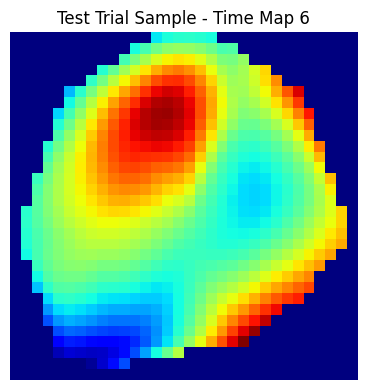

In [17]:
# Choose a completely random sample out of your 10% test array
random_trial_idx = random.randint(0, len(X_test) - 1)
single_sample = X_test[random_trial_idx]
single_true_label = allYTrue[random_trial_idx]

# Reshape sample to append the expected batch dimension: [1, H, W, C, T]
single_sample_batch = np.expand_dims(single_sample, axis=0)

# Execute inference
predicted_probabilities = model.predict(single_sample_batch)
predicted_class_idx = np.argmax(predicted_probabilities, axis=1)[0]

print(f"\n--- Single-Trial Verification ---")
print(f"True Label: {classNames[single_true_label]}")
print(f"Model Prediction: {classNames[predicted_class_idx]}")

# Plotting a quick reference map from the chosen test trial
# single_sample shape format: [H, W, C, T] -> Select a random slice along the time axis (T)
H_dim, W_dim, _, T_dim = single_sample.shape
random_map_idx = random.randint(0, T_dim - 1)
img_slice = single_sample[:, :, :, random_map_idx]

plt.figure(figsize=(4, 4))
plt.imshow(img_slice)
plt.title(f'Test Trial Sample - Time Map {random_map_idx + 1}')
plt.axis('off')
plt.tight_layout()
plt.show()